# <font color='#11a642' size='6'> Импорт и установка библиотек



In [2]:
# установка дополнительной библиотеки
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.1 MB/s eta 0:00:00


In [3]:
!pip uninstall numpy

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/numpy-config
    /usr/local/lib/python3.11/dist-packages/numpy-2.0.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libscipy_openblas64_-99b71e71.so
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? Y
  Successfully uninstalled numpy-2.0.2


In [4]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 48.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd # работа с таблицами
import numpy as np # математические вычисления
from scipy import stats # статистические методы
import matplotlib
import matplotlib.pyplot as plt # визуализация данных


from statsmodels.tsa.stattools import adfuller # тест Дики-Фуллера

from sklearn.metrics import mean_absolute_percentage_error as MAPE
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose # оценка сезонности
from statsmodels.tsa.statespace.sarimax import SARIMAX # Построить модель SARIMAX
from sklearn.metrics import mean_squared_error # метрика качества MSE
from statsmodels.tools.eval_measures import rmse  # метрика качества Квадратный корень из MSE

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from pmdarima import auto_arima # автоматический подбор параметров

In [2]:
np.__version__

'1.26.4'

# <font color='#11a642' size='6'> Загрузка данных


In [3]:
!gdown 1PPoqphp2ousTp56rTtIwvSQBT544BsyI

Downloading...
From: https://drive.google.com/uc?id=1PPoqphp2ousTp56rTtIwvSQBT544BsyI
To: /content/shampoo_sales.csv
100% 484/484 [00:00<00:00, 1.64MB/s]


In [4]:
try:
  df = pd.read_csv('shampoo_sales.csv')
except:
  df = pd.read_csv('/content/shampoo_sales.csv')

In [5]:
df.head()

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3


# <font color='#11a642' size='6'> Провести разведочный анализ данных (EDA)

In [444]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   36 non-null     object 
 1   Sales   36 non-null     float64
dtypes: float64(1), object(1)
memory usage: 708.0+ bytes


In [445]:
df['Month'].unique()

array(['1-01', '1-02', '1-03', '1-04', '1-05', '1-06', '1-07', '1-08',
       '1-09', '1-10', '1-11', '1-12', '2-01', '2-02', '2-03', '2-04',
       '2-05', '2-06', '2-07', '2-08', '2-09', '2-10', '2-11', '2-12',
       '3-01', '3-02', '3-03', '3-04', '3-05', '3-06', '3-07', '3-08',
       '3-09', '3-10', '3-11', '3-12'], dtype=object)

In [6]:
# 1. Преобразование данных
df['date'] = df['Month'].map(lambda x: '200'+x)

In [447]:
df

,Month,Sales,date
0,1-01,266.0,2001-01
1,1-02,145.9,2001-02
2,1-03,183.1,2001-03
3,1-04,119.3,2001-04
4,1-05,180.3,2001-05
5,1-06,168.5,2001-06
6,1-07,231.8,2001-07
7,1-08,224.5,2001-08
8,1-09,192.8,2001-09
9,1-10,122.9,2001-10


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   36 non-null     object 
 1   Sales   36 non-null     float64
 2   date    36 non-null     object 
dtypes: float64(1), object(2)
memory usage: 996.0+ bytes


In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Month   36 non-null     object        
 1   Sales   36 non-null     float64       
 2   date    36 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 996.0+ bytes


In [10]:
df

,Month,Sales,date
0,1-01,266.0,2001-01-01
1,1-02,145.9,2001-02-01
2,1-03,183.1,2001-03-01
3,1-04,119.3,2001-04-01
4,1-05,180.3,2001-05-01
5,1-06,168.5,2001-06-01
6,1-07,231.8,2001-07-01
7,1-08,224.5,2001-08-01
8,1-09,192.8,2001-09-01
9,1-10,122.9,2001-10-01


In [11]:

df = df.set_index('date').sort_index()
ts = df['Sales']

In [450]:
print("="*50)
print("1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*50)
print(f"Период данных: {ts.index.min()} - {ts.index.max()}")
print(f"Количество наблюдений: {len(ts)}")
print("\nПервые 5 строк:")
print(ts.head())
print("\nОписательная статистика:")
print(ts.describe())

1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ
Период данных: 2001-01-01 00:00:00 - 2003-12-01 00:00:00
Количество наблюдений: 36

Первые 5 строк:
date
2001-01-01    266.0
2001-02-01    145.9
2001-03-01    183.1
2001-04-01    119.3
2001-05-01    180.3
Name: Sales, dtype: float64

Описательная статистика:
count     36.000000
mean     312.600000
std      148.937164
min      119.300000
25%      192.450000
50%      280.150000
75%      411.100000
max      682.000000
Name: Sales, dtype: float64



2. ВИЗУАЛИЗАЦИЯ


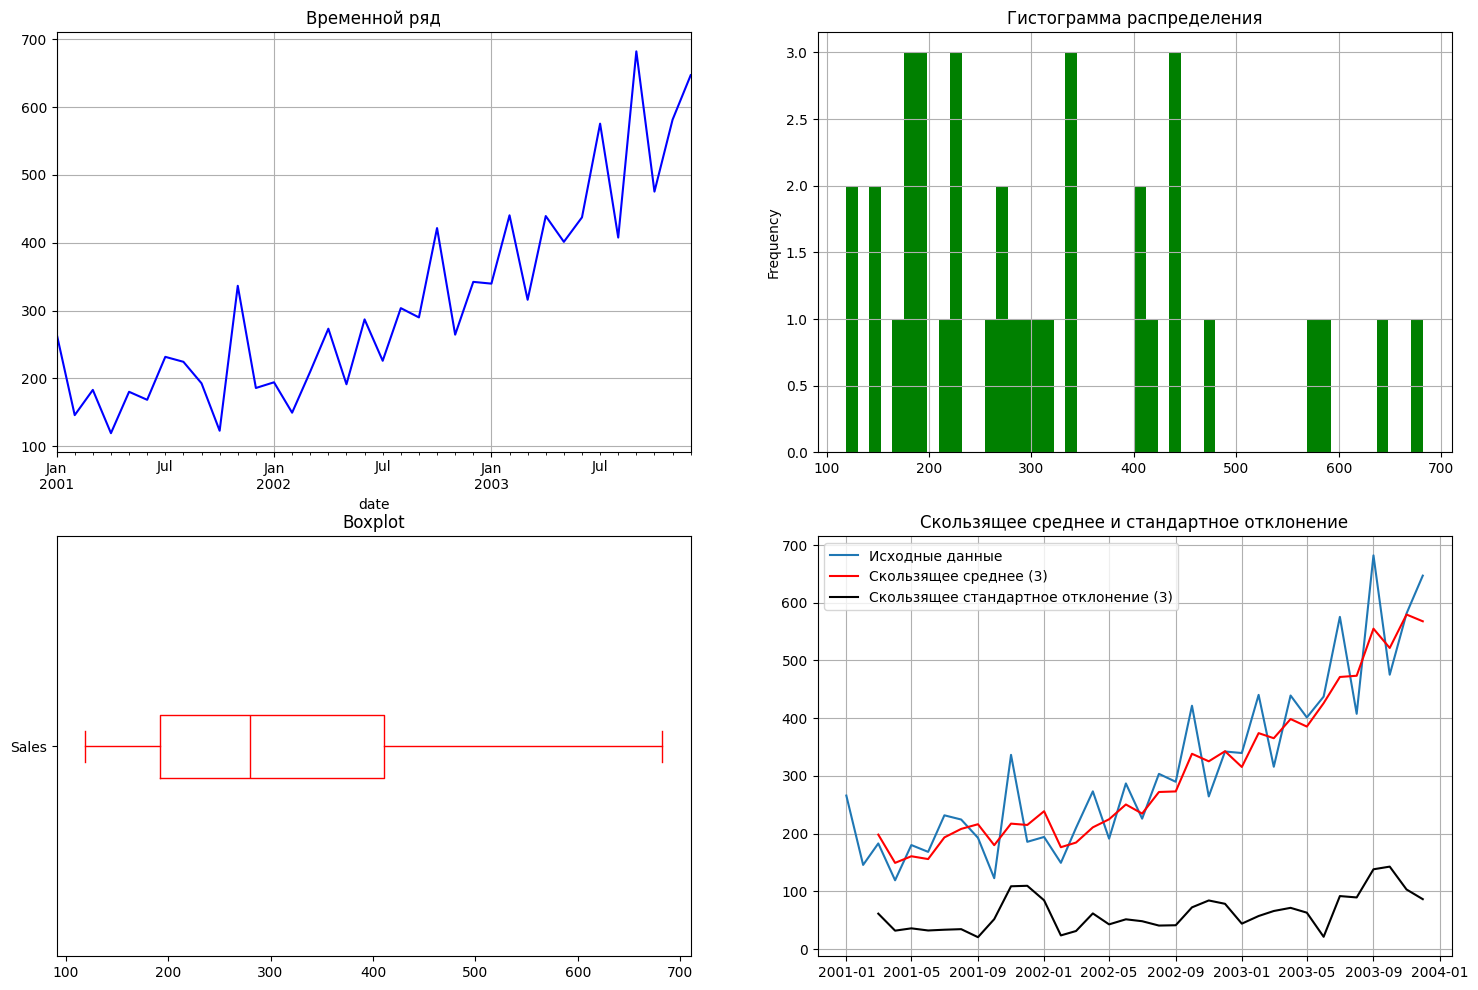

In [451]:
# 2. Визуализация временного ряда
print("\n" + "="*50)
print("2. ВИЗУАЛИЗАЦИЯ")
print("="*50)

plt.figure(figsize=(18, 12))

# Основной график временного ряда
plt.subplot(2, 2, 1)
ts.plot(title='Временной ряд', color='blue')
plt.grid(True)
# График распределения
plt.subplot(2, 2, 2)
ts.plot(kind='hist', bins=50, title='Гистограмма распределения', color='green')
plt.grid(True)
# График boxplot
plt.subplot(2, 2, 3)
ts.plot(kind='box', title='Boxplot', vert=False, color='red')
# Скользящее среднее
plt.subplot(2, 2, 4)
rolling_mean = ts.rolling(window=3).mean()
rolling_std = ts.rolling(window=3).std()
plt.plot(ts, label='Исходные данные')
plt.plot(rolling_mean, label='Скользящее среднее (3)', color='red')
plt.plot(rolling_std, label='Скользящее стандартное отклонение (3)', color='black')
plt.title('Скользящее среднее и стандартное отклонение')
plt.legend()
plt.grid(True)

# <font color='#11a642' size='6'> Разделить данные на тестовую и тренировочную выборку

In [12]:
TEST_SIZE = 11
train= ts.iloc[:len(ts)-TEST_SIZE]
test= ts.iloc[len(ts)-TEST_SIZE:]

In [453]:
train

,Sales
date,
2001-01-01,266.0
2001-02-01,145.9
2001-03-01,183.1
2001-04-01,119.3
2001-05-01,180.3
2001-06-01,168.5
2001-07-01,231.8
2001-08-01,224.5
2001-09-01,192.8


In [13]:
test

,Sales
date,
2003-02-01,440.4
2003-03-01,315.9
2003-04-01,439.3
2003-05-01,401.3
2003-06-01,437.4
2003-07-01,575.5
2003-08-01,407.6
2003-09-01,682.0
2003-10-01,475.3


## <font color='#11a642' size='5'>Автокорреляция


3. ВИЗУАЛИЗАЦИЯ (Автокорреляция и частичная автокорреляция)


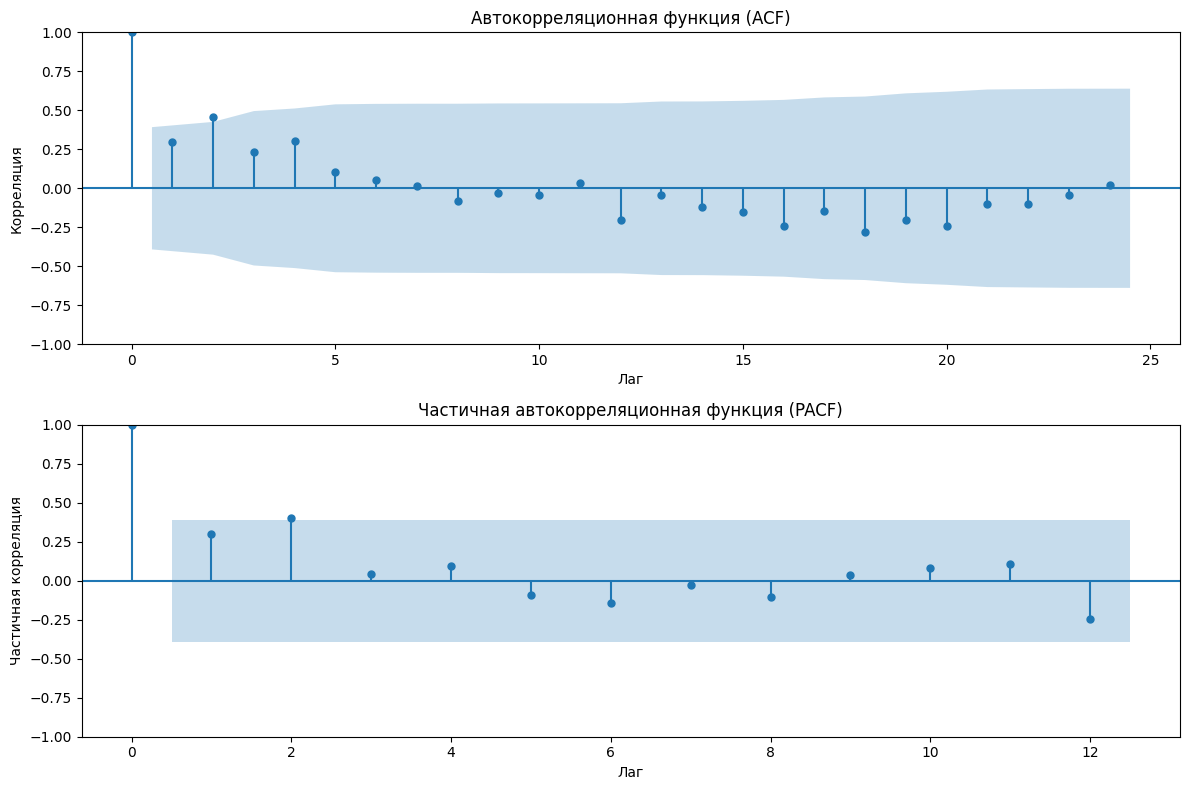

In [455]:
print("\n" + "="*50)
print("3. ВИЗУАЛИЗАЦИЯ (Автокорреляция и частичная автокорреляция)")
print("="*50)

# Определяем количество лагов автоматически (но не более 30)
max_lags = min(30, len(train)-1)  # Обеспечиваем, чтобы лагов было меньше длины ряда

plt.figure(figsize=(12, 8))

# График ACF
plt.subplot(2, 1, 1)
plot_acf(train, lags=max_lags, ax=plt.gca(), alpha=0.05)  # Добавляем доверительный интервал 95%
plt.title('Автокорреляционная функция (ACF)')
plt.xlabel('Лаг')
plt.ylabel('Корреляция')

# График PACF
plt.subplot(2, 1, 2)
plot_pacf(train, lags=max_lags//2, ax=plt.gca(), alpha=0.05)
plt.title('Частичная автокорреляционная функция (PACF)')
plt.xlabel('Лаг')
plt.ylabel('Частичная корреляция')

plt.tight_layout()
plt.show()

# <font color='#11a642' size='6'> тест на стационарность ряда

In [17]:
def adf_test(series,title=''):
  '''
  тест Дики-Фуллера
  0 гипотеза: ряд данных не стационарен
  альтернативная гипотеза: ряд данных стационарен
  Понятие стационарного временного ряда означает, что его среднее значение не изменяется во времени, т. е. временной ряд не имеет тренда
  @param series - значения ряда
  @param title - заголовок ряда
  '''

  result = adfuller(series.dropna(),autolag='AIC')

  labels = ['ADF тест','p-value','# lags used','# наблюдения']
  out = pd.Series(result[0:4],index=labels)

  for key,val in result[4].items():
      out[f'критическое значение ({key})']=val

  print(out.to_string())

  if result[1] <= 0.05:
      print("Сильные доказательства против нулевой гипотезы")
      print("Отменяем 0 гипотезу")
      print("Данные стационарны")
  else:
      print("Слабые доказательства против нулевой гипотезы")
      print("Не отменяем 0 гипотезу")
      print("Данные не стационарны")

In [457]:
adf_test(train)

ADF тест                      -1.085206
p-value                        0.720935
# lags used                    1.000000
# наблюдения                  23.000000
критическое значение (1%)     -3.752928
критическое значение (5%)     -2.998500
критическое значение (10%)    -2.638967
Слабые доказательства против нулевой гипотезы
Не отменяем 0 гипотезу
Данные не стационарны


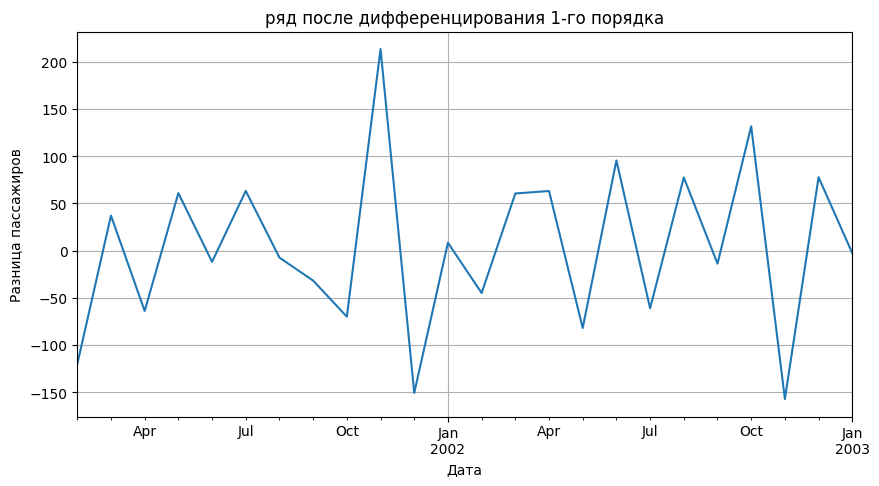

In [15]:
# Сконвертируем нестационарный ряд в стационарный
# Понятие стационарного временного ряда означает, что его статистические свойства (среднее, дисперсия)
# не изменяются во времени, т.е. временной ряд не имеет тренда и сезонности

# Используем метод differencing (дифференцирование)
# train["difference_1"] = train.diff(periods=1)  # periods=1 - разница с предыдущим значением

# Удаляем первую строку с NaN (результат дифференцирования)
ts_diff_1 = train.diff(periods=1).dropna()

# Визуализируем результат
plt.figure(figsize=(10, 5))
ts_diff_1.plot(title='ряд после дифференцирования 1-го порядка')
plt.xlabel('Дата')
plt.ylabel('Разница пассажиров')
plt.grid(True)
plt.show()

In [18]:
adf_test(ts_diff_1)

ADF тест                     -1.051192e+01
p-value                       1.019266e-18
# lags used                   0.000000e+00
# наблюдения                  2.300000e+01
критическое значение (1%)    -3.752928e+00
критическое значение (5%)    -2.998500e+00
критическое значение (10%)   -2.638967e+00
Сильные доказательства против нулевой гипотезы
Отменяем 0 гипотезу
Данные стационарны



3. ВИЗУАЛИЗАЦИЯ (Автокорреляция и частичная автокорреляция)


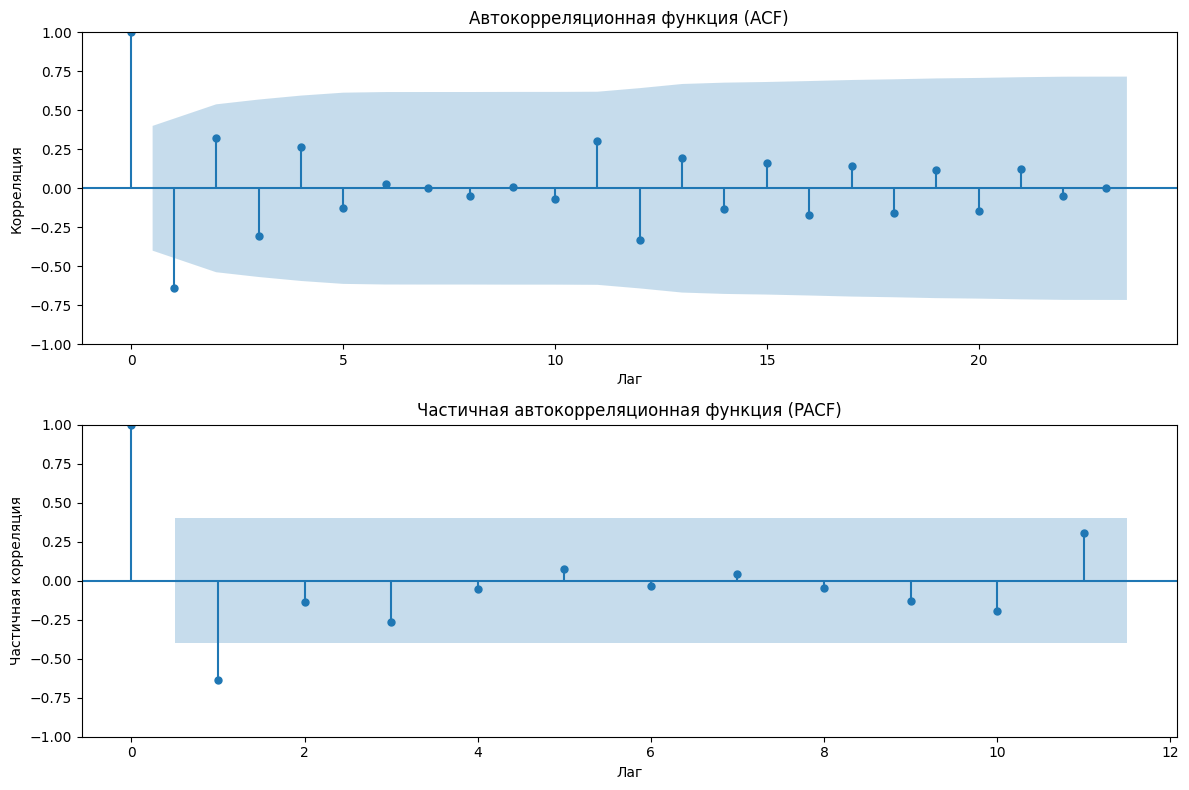

In [21]:
print("\n" + "="*50)
print("3. ВИЗУАЛИЗАЦИЯ (Автокорреляция и частичная автокорреляция)")
print("="*50)

# Определяем количество лагов автоматически (но не более 30)
max_lags = min(30, len(ts_diff_1)-1)  # Обеспечиваем, чтобы лагов было меньше длины ряда

plt.figure(figsize=(12, 8))

# График ACF
plt.subplot(2, 1, 1)
plot_acf(ts_diff_1, lags=max_lags, ax=plt.gca(), alpha=0.05)  # Добавляем доверительный интервал 95%
plt.title('Автокорреляционная функция (ACF)')
plt.xlabel('Лаг')
plt.ylabel('Корреляция')

# График PACF
plt.subplot(2, 1, 2)
plot_pacf(ts_diff_1, lags=max_lags//2, ax=plt.gca(), alpha=0.05)
plt.title('Частичная автокорреляционная функция (PACF)')
plt.xlabel('Лаг')
plt.ylabel('Частичная корреляция')

plt.tight_layout()
plt.show()

# <font color='#11a642' size='6'> Модель ARIMA
Автоматически подобрать параметры для ряда с помощью auto_arima. Выбрать оптимальные значения

In [461]:
type(ts_diff_1)

pandas.core.series.Series

In [462]:
# Вызов функции auto_arima для автоматического подбора ARIMA-модели
auto_arima_results = auto_arima(
    # Исходный временной ряд (уже продифференцированный на 1 лаг)
    ts_diff_1,

    # Параметры несезонной AR-компоненты (авторегрессия)
    start_p=0,    # Начальное значение порядка p (AR)
    max_p=3,      # Максимальный порядок p (AR)

    # Параметры несезонной MA-компоненты (скользящее среднее)
    start_q=0,    # Начальное значение порядка q (MA)
    max_q=3,      # Максимальный порядок q (MA)

    # Дифференцирование (интегрированная часть, I)
    d=None,       # Автоматический подбор порядка дифференцирования (None = определит сам)

    # Сезонные настройки (отключены, т.к. seasonal=False)
    seasonal=False,  # Если True, модель будет SARIMA (сезонная ARIMA)
    m=1,          # Период сезонности (1 = нет сезонности)
    start_P=0,    # Начальный порядок сезонной авторегрессии (P)
    D=0,          # Порядок сезонного дифференцирования (0 = нет)

    # Настройки процесса подбора модели
    trace=True,          # Вывод лога подбора моделей
    error_action='ignore',  # Действие при ошибке ('ignore', 'warn', 'raise')
    stepwise=True,       # Пошаговый подбор (быстрее, но менее точный)

)
auto_arima_results.summary()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=284.988, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=273.935, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=274.315, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=275.267, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=274.034, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=275.970, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=275.524, Time=0.05 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.282 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   24
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -134.968
Date:                Thu, 03 Jul 2025   AIC                            273.935
Time:                        02:14:28   BIC                            276.291
Sample:                    02-01-2001   HQIC                           274.560
                         - 01-01-2003                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6563      0.191     -3.442      0.001      -1.030      -0.283
sigma2      4385.2752   1323.532      3.313      0.001    1791.201    6979.350
===================================================================================
Ljung-Box (L1) (Q):                   0.20   Jarque-Bera (JB):                 0.95
Prob(Q):                              0.66   Prob(JB):                         0.62
Heteroskedasticity (H):               1.51   Skew:                             0.48
Prob(H) (two-sided):                  0.57   Kurtosis:                         2.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [463]:
train

,Sales
date,
2001-01-01,266.0
2001-02-01,145.9
2001-03-01,183.1
2001-04-01,119.3
2001-05-01,180.3
2001-06-01,168.5
2001-07-01,231.8
2001-08-01,224.5
2001-09-01,192.8


In [464]:
# найдем порядок p,d,q
# ARIMA: обучение модели без сезонной составляющей
auto_arima_results= auto_arima(train,
           start_p=0,
           start_q=0,
           max_p=3,
           max_q=3,
           m=1,
           d=None,
           seasonal=False,
           start_P=0,
           D=0,
           trace=True,
           error_action='ignore',
           stepwise=True)

auto_arima_results.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=286.959, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=275.485, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=284.988, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=276.604, Time=0.26 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=273.183, Time=0.96 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.85 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=273.521, Time=0.60 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=273.988, Time=0.05 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 3.619 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   25
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -132.591
Date:                Thu, 03 Jul 2025   AIC                            273.183
Time:                        02:14:34   BIC                            277.895
Sample:                    01-01-2001   HQIC                           274.433
                         - 01-01-2003                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      9.1799      4.474      2.052      0.040       0.411      17.949
ar.L1         -0.3234      0.437     -0.740      0.459      -1.180       0.533
ma.L1         -0.7768      0.342     -2.268      0.023      -1.448      -0.106
sigma2      3470.6572   1076.999      3.223      0.001    1359.779    5581.536
===================================================================================
Ljung-Box (L1) (Q):                   0.27   Jarque-Bera (JB):                 1.04
Prob(Q):                              0.60   Prob(JB):                         0.59
Heteroskedasticity (H):               1.24   Skew:                             0.50
Prob(H) (two-sided):                  0.77   Kurtosis:                         3.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [466]:
train.index.inferred_freq

'MS'

In [25]:
# обучим модель ARIMA используя p,d,q из полученного результата по auto_arima
arima_model= ARIMA(train, order= (1,1,0),freq='MS')
arima_model_fit= arima_model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [26]:
# сделаем прогноз на test наборе данных
start= len(train)
end= len(train) + len(test) -1

pred= arima_model_fit.predict(start=start, end=end, dynamic=False, typ="levels").rename("ARIMA predictions")

<Axes: title={'center': 'Факт и Прогноз для Test набора данных'}, xlabel='date'>

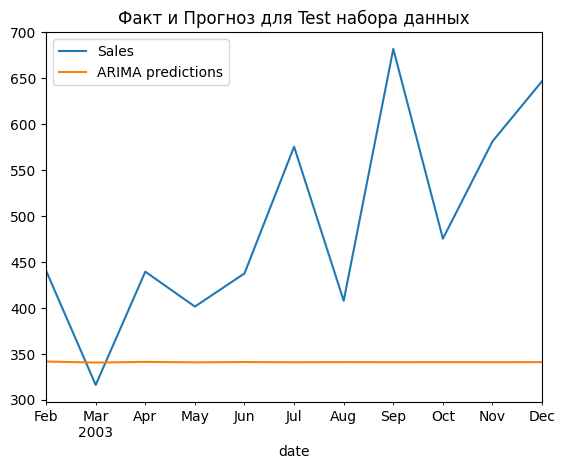

In [27]:
title= "Факт и Прогноз для Test набора данных"
test.plot(title= title, legend=True);
pred.plot(legend=True)

In [28]:
# оценим модель по штрафным баллам
mse= mean_squared_error(test,pred)
rmse_arima= rmse(test, pred)

print(f"RMSE= {rmse_arima} \n")
print(f"MSE= {mse}")

RMSE= 185.5925006688841 

MSE= 34444.57630452974


In [472]:
# Получение данных после прогноза
forecast_steps = 30  # Количество шагов для прогнозирования
arima_model_fit.forecast(steps=forecast_steps)
 # Этот метод вернет объект с датами и значениями прогноза

,predicted_mean
2003-02-01,341.408134
2003-03-01,340.285933
2003-04-01,341.023191
2003-05-01,340.538831
2003-06-01,340.857043
2003-07-01,340.647986
2003-08-01,340.785331
2003-09-01,340.695099
2003-10-01,340.754379
2003-11-01,340.715434


#<font color='#11a642' size='6'> SARIMA

In [473]:
# найдем порядок p,d,q, сезонность P, D, Q
# ARIMA: обучение модели с сезонной составляющей
smodel = auto_arima(train,
                    start_p=0,
                    start_q=0,
                    max_p=3,
                    max_q=3,
                    m=12,
                    start_P=0,
                    seasonal=True,
                    d=None,
                    D=None,
                    trace=True,
                    error_action='ignore',
                    suppress_warnings=True,
                    stepwise=True)

smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.56 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=286.959, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=272.381, Time=0.33 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=284.988, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=275.485, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=274.368, Time=0.42 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=274.368, Time=0.30 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=276.368, Time=0.33 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=282.107, Time=0.11 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=273.242, Time=0.19 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(2,1,1)(1,0,0)[12] intercept   : AIC=inf, Time=

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   25
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 12)   Log Likelihood                -132.756
Date:                            Thu, 03 Jul 2025   AIC                            271.512
Time:                                    02:14:51   BIC                            275.046
Sample:                                01-01-2001   HQIC                           272.450
                                     - 01-01-2003                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6490      0.231     -2.804      0.005      -1.103      -0.195
ar.S.L12      -0.5547      0.274     -2.028      0.043      -1.091      -0.019
sigma2      3043.4348   1365.881      2.228      0.026     366.357    5720.512
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.90
Prob(Q):                              0.84   Prob(JB):                         0.64
Heteroskedasticity (H):               1.17   Skew:                             0.47
Prob(H) (two-sided):                  0.83   Kurtosis:                         3.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [475]:
# обучим модель
sarima_model= SARIMAX(train, order= (1,1,0), seasonal_order= (1,0,0,12))
sarima_model_fit= sarima_model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



In [476]:
# сделаем прогнозы на Test данных
start= len(train)
end= len(train) + len(test) -1
pred= sarima_model_fit.predict(start=start, end=end, dynamic=False, typ="levels").rename("SARIMA predictions")


<Axes: title={'center': 'Актуальность и прогноз для Test данных'}, xlabel='date'>

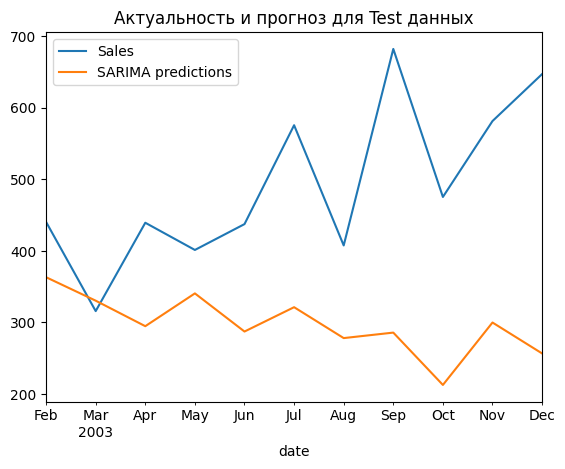

In [477]:
# построим прогноз
title= "Актуальность и прогноз для Test данных"
test.plot(title= title, legend=True)
pred.plot(legend=True)

In [478]:
# оценим модель
mse= mean_squared_error(test,pred)
rmse_sarima= rmse(test, pred)

print(f"RMSE= {rmse_sarima} \n")
print(f"MSE= {mse}")

RMSE= 231.9289605724554 

MSE= 53791.042752219575


In [29]:
# подсчитаем сезонный индекс
result_mul = seasonal_decompose(train,   # 3 years
                                model='multiplicative',
                                extrapolate_trend='freq')

seasonal_index = result_mul.seasonal[-12:].to_frame()
seasonal_index['month'] = pd.to_datetime(seasonal_index.index).month

In [30]:
seasonal_index

,seasonal,month
date,,
2002-02-01,0.780739,2
2002-03-01,0.990999,3
2002-04-01,0.878918,4
2002-05-01,0.862401,5
2002-06-01,0.985149,6
2002-07-01,0.968593,7
2002-08-01,1.105148,8
2002-09-01,0.986274,9
2002-10-01,1.016205,10


In [31]:
# соединим его с Train данными
train = train.reset_index()
train['month'] = train['date'].dt.month
train
train2 = pd.merge(train, seasonal_index, how='left', on='month')
train2
train2.index = train.index  # переопределим первичный индекс

In [32]:
test = test.reset_index()
test['month'] = test['date'].dt.month

test2 = pd.merge(test, seasonal_index, how='left', on='month')
test2.index = test.index
test2

,date,Sales,month,seasonal
0,2003-02-01,440.4,2,0.780739
1,2003-03-01,315.9,3,0.990999
2,2003-04-01,439.3,4,0.878918
3,2003-05-01,401.3,5,0.862401
4,2003-06-01,437.4,6,0.985149
5,2003-07-01,575.5,7,0.968593
6,2003-08-01,407.6,8,1.105148
7,2003-09-01,682.0,9,0.986274
8,2003-10-01,475.3,10,1.016205
9,2003-11-01,581.3,11,1.218666


In [484]:
# SARIMAX модель
sxmodel = auto_arima(train2["Sales"],
                     exogenous=train2[['seasonal']],
                    start_p=0,
                    start_q=0,
                    max_p=3,
                    max_q=3,
                    m=12,
                    start_P=0,
                    seasonal=True,
                    d=None,
                    D=None,
                    trace=True,
                    error_action='ignore',
                    suppress_warnings=True,
                    stepwise=True)

sxmodel.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=286.959, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=272.381, Time=0.15 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=284.988, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=275.485, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=274.368, Time=0.47 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=274.368, Time=0.30 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=276.368, Time=0.35 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=282.107, Time=0.11 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=273.242, Time=0.21 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(2,1,1)(1,0,0)[12] intercept   : AIC=inf, Time=

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   25
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 12)   Log Likelihood                -132.756
Date:                            Thu, 03 Jul 2025   AIC                            271.512
Time:                                    02:15:07   BIC                            275.046
Sample:                                         0   HQIC                           272.450
                                             - 25                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6490      0.231     -2.804      0.005      -1.103      -0.195
ar.S.L12      -0.5547      0.274     -2.028      0.043      -1.091      -0.019
sigma2      3043.4348   1365.881      2.228      0.026     366.357    5720.512
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.90
Prob(Q):                              0.84   Prob(JB):                         0.64
Heteroskedasticity (H):               1.17   Skew:                             0.47
Prob(H) (two-sided):                  0.83   Kurtosis:                         3.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [33]:
# обучение модели
sarimax_model= SARIMAX(train2["Sales"], order= (1,1,0), seasonal_order= (1,0,0,12),exog=train2[['seasonal']])
sarimax_model_fit= sarimax_model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


In [34]:
# прогнозы на Test
start= 0
end= len(test) -1
pred= sarimax_model_fit.predict(start=start, end=end, dynamic=False, typ="levels",exog=test2[['seasonal']]).rename("SARIMAX with Exog")

<Axes: title={'center': 'Актуальность и прогноз для Test данных'}>

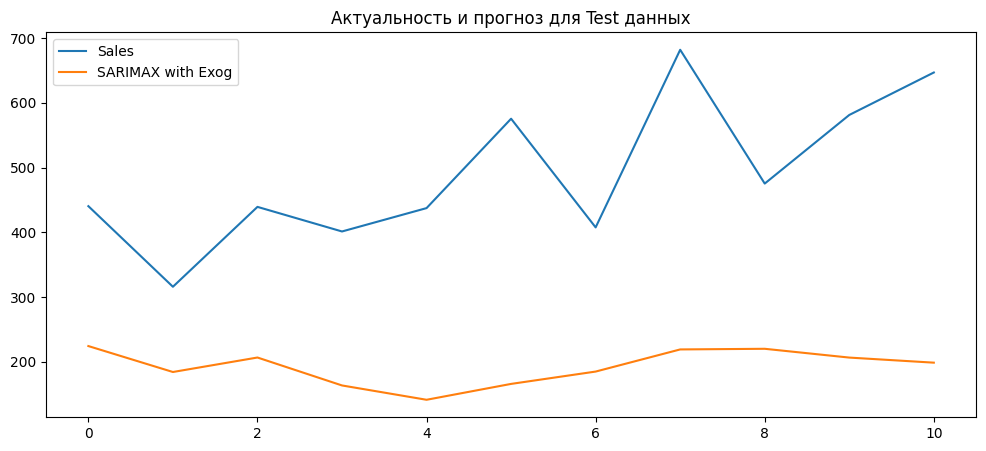

In [35]:
title= "Актуальность и прогноз для Test данных"
test["Sales"].plot(figsize=(12,5), title= title, legend=True)
pred.plot(legend=True)

# <font color='#11a642' size='6'> Модель PROPHET

Теперь построим модель Prophit. Для этой модели нужна специфическая настройка датасета. Столбец с датой должен называться 'ds', а столбец с данными 'y'.

In [488]:
df_prophet = df.reset_index().copy()[['date', 'Sales']]
df_prophet.columns = ['ds', 'y']
df_prophet.head()

,ds,y
0,2001-01-01,266.0
1,2001-02-01,145.9
2,2001-03-01,183.1
3,2001-04-01,119.3
4,2001-05-01,180.3


Снова разделим данные на тренировочную и тестовую выборку. Следует учитывать специфику Prophet, он плохо взаимодействует с очень большими временными рядами, на несколько сотен лет, поэтому отрежем 30 лет от начала датасета, во избежание ошибок библиотеки. Количество лет установленно экспериментально.

In [489]:
train_prophet = df_prophet[:-11]
test_prophet = df_prophet[-11:]

In [491]:
model = Prophet()

model.fit(train_prophet)
future = model.make_future_dataframe(periods=15, freq='MS')
forecast = model.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3hbqeq44/gdcnrvw_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3hbqeq44/0_pnfoee.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=78082', 'data', 'file=/tmp/tmp3hbqeq44/gdcnrvw_.json', 'init=/tmp/tmp3hbqeq44/0_pnfoee.json', 'output', 'file=/tmp/tmp3hbqeq44/prophet_model02z41sxq/prophet_model-20250703021517.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
02:15:17 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:15:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:

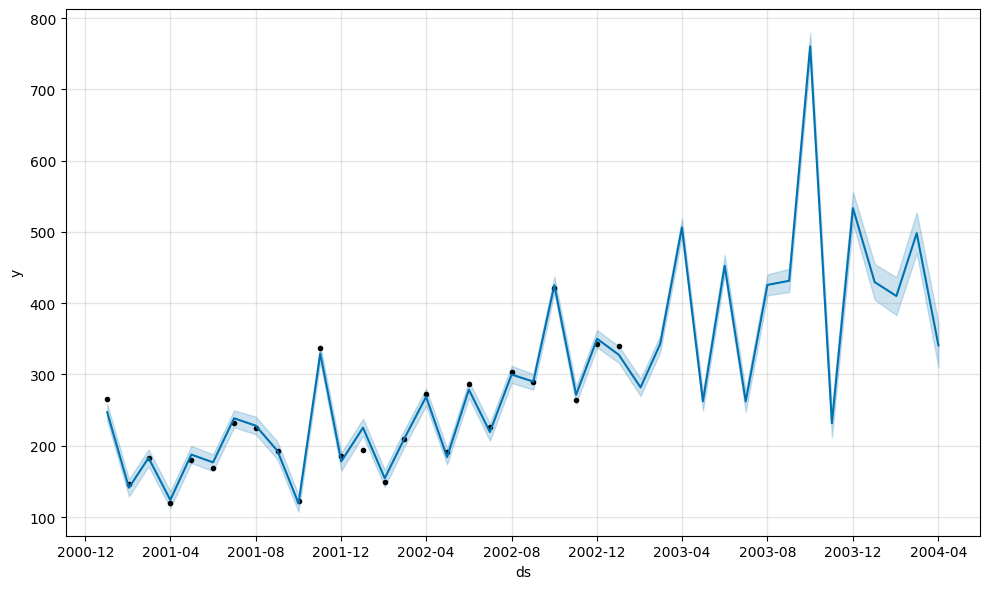

In [492]:
ax = model.plot(forecast)

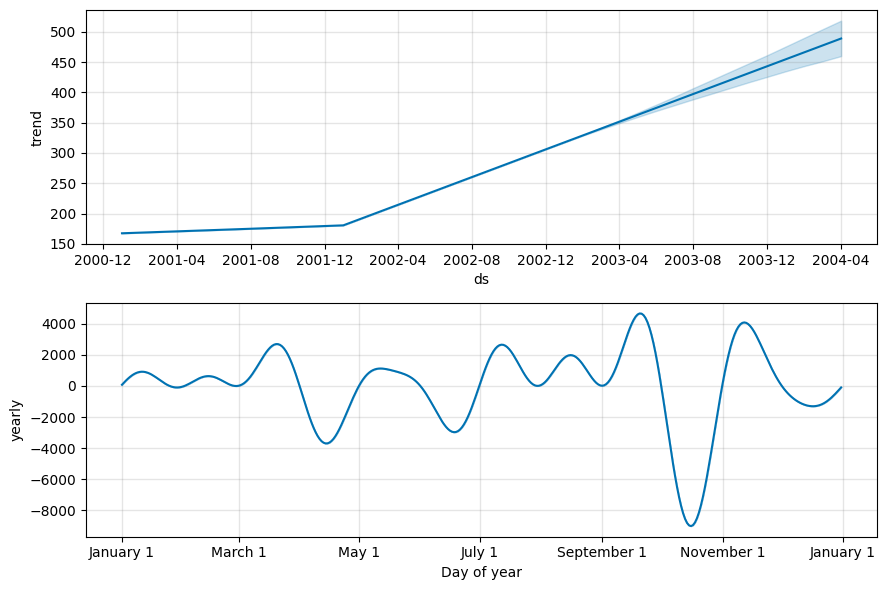

In [493]:
fig_components = model.plot_components(forecast)

In [494]:
p_prediction = test_prophet.set_index('ds').join(forecast.set_index('ds')[['yhat']][-15:])
p_prediction

,y,yhat
ds,,
2003-02-01,440.4,281.834103
2003-03-01,315.9,342.840713
2003-04-01,439.3,506.340467
2003-05-01,401.3,262.403261
2003-06-01,437.4,452.583886
2003-07-01,575.5,262.260225
2003-08-01,407.6,425.751904
2003-09-01,682.0,431.495634
2003-10-01,475.3,760.415742


In [496]:
mse = mean_squared_error(p_prediction['y'], p_prediction['yhat'])
print('Prophet')
print('MAPE:', MAPE(p_prediction['y'], p_prediction['yhat']))
print('RMSE:', mse**.5)
print('MSE:', mse)

Prophet
MAPE: 0.30107946911943884
RMSE: 197.16181725336332
MSE: 38872.78218264863


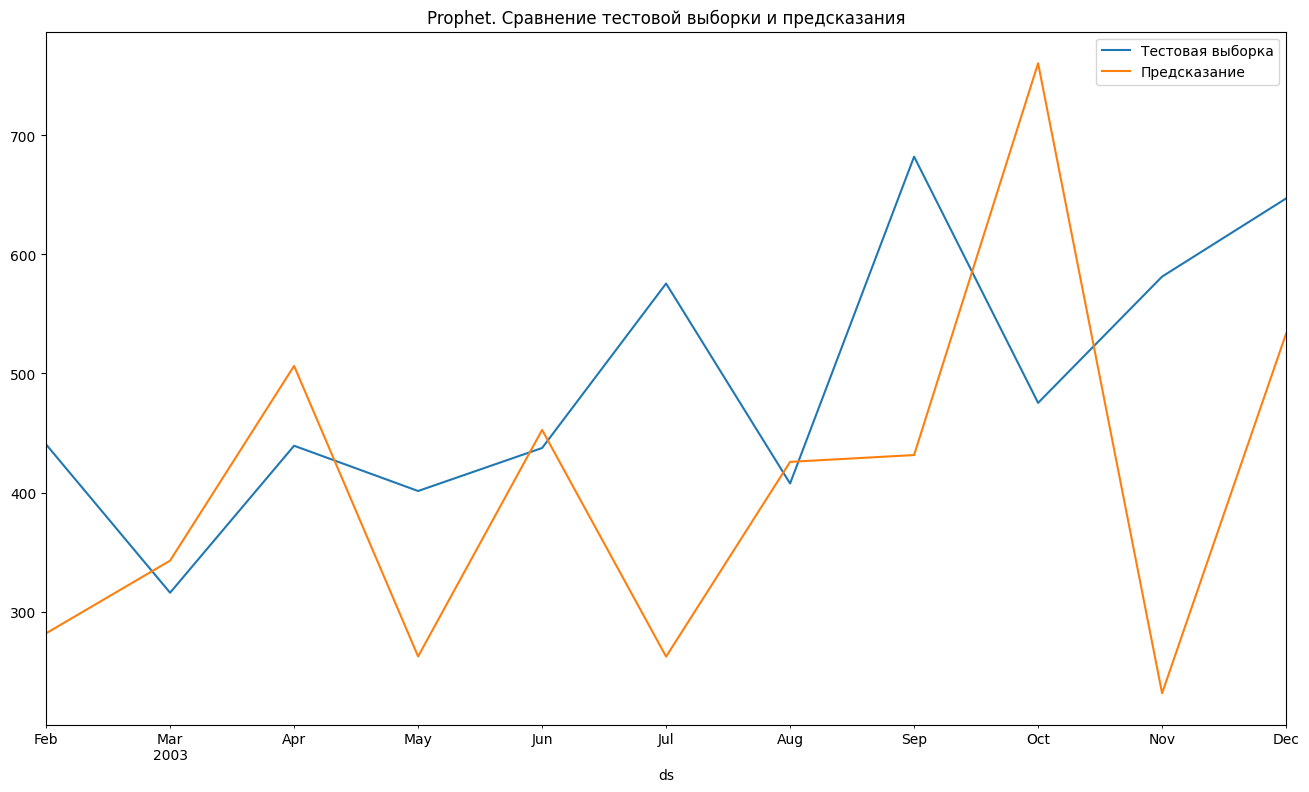

In [497]:
ax1 = p_prediction['y'].plot(legend=True, title='Prophet. Сравнение тестовой выборки и предсказания')
ax2 = p_prediction['yhat'].plot(figsize=(16,9), legend=True) \
  .legend(['Тестовая выборка', 'Предсказание'])

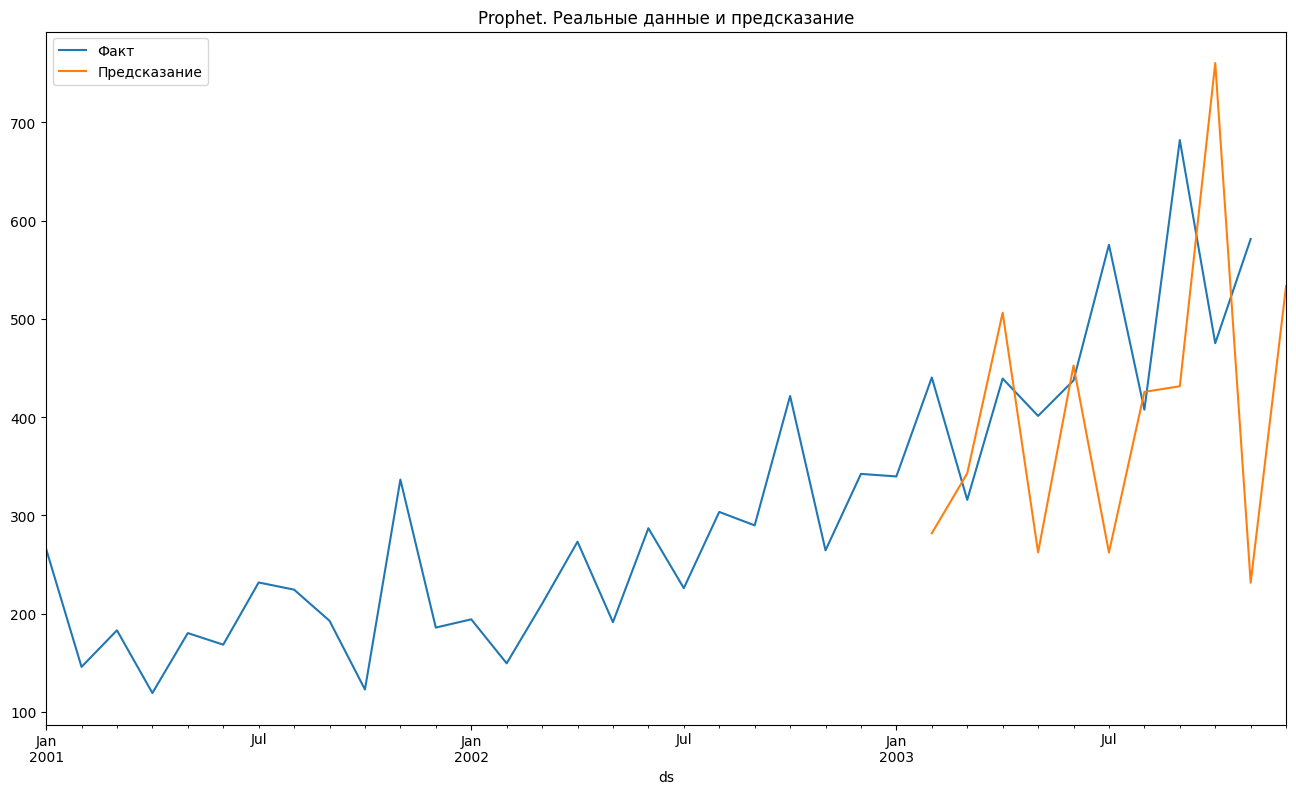

In [498]:
ax1 = df_prophet[:-1].set_index('ds').plot(title='Prophet. Реальные данные и предсказание')
ax2 = p_prediction['yhat'][-17:].plot(figsize=(16,9)) \
  .legend(['Факт', 'Предсказание'])

In [499]:
# Создание и настройка модели Prophet
model_mult = Prophet(
    seasonality_mode='multiplicative',
    # Основные настройки
    growth='linear',       # Тип тренда ('linear', 'logistic', 'flat')
    changepoint_prior_scale=15,  # Гибкость тренда (чем больше, тем гибче)
    seasonality_prior_scale=15.0,  # Сила сезонности (меньше = менее резкие колебания)

    # Настройки сезонности
    yearly_seasonality='auto',  # Автоподбор годовой сезонности
    weekly_seasonality=False,    # Учитывать недельную сезонность
    daily_seasonality=False,    # Отключить дневную сезонность (если не нужно)

    # Учет праздников и особых дней
    holidays=None,              # Можно добавить DataFrame с праздниками

)


# Обучение модели
model_mult.fit(train_prophet)

INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3hbqeq44/bmlkbobc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3hbqeq44/uhewyt8q.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=15521', 'data', 'file=/tmp/tmp3hbqeq44/bmlkbobc.json', 'init=/tmp/tmp3hbqeq44/uhewyt8q.json', 'output', 'file=/tmp/tmp3hbqeq44/prophet_modelo48q4tbl/prophet_model-20250703021528.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
02:15:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:15:43 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [500]:
future = model_mult.make_future_dataframe(periods=15, freq='MS')
forecast = model_mult.predict(future)

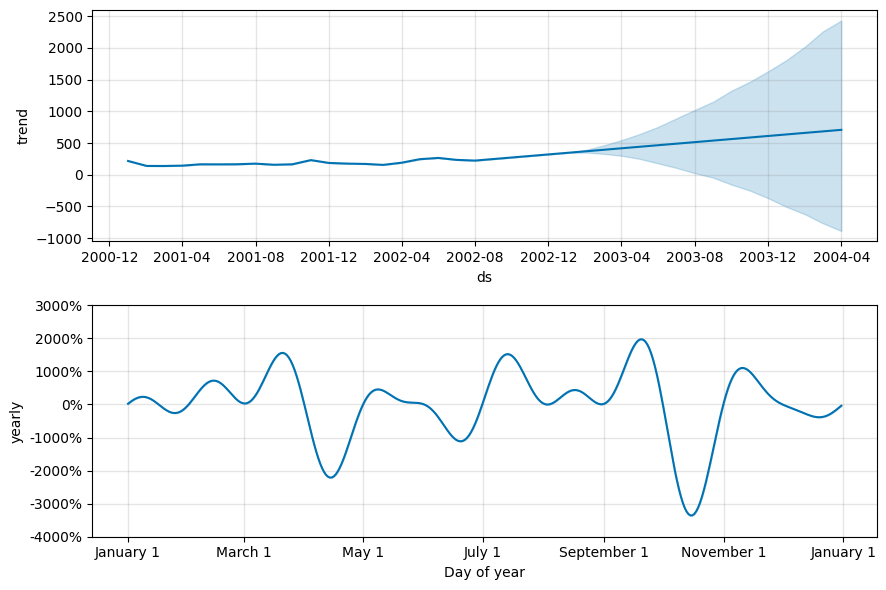

In [501]:
fig_components = model_mult.plot_components(forecast)

In [502]:
p_prediction = test_prophet.set_index('ds').join(forecast.set_index('ds')[['yhat']][-15:])
p_prediction

,y,yhat
ds,,
2003-02-01,440.4,262.891208
2003-03-01,315.9,543.255608
2003-04-01,439.3,848.489803
2003-05-01,401.3,201.430732
2003-06-01,437.4,527.343034
2003-07-01,575.5,258.030355
2003-08-01,407.6,742.185244
2003-09-01,682.0,605.297052
2003-10-01,475.3,1318.576609


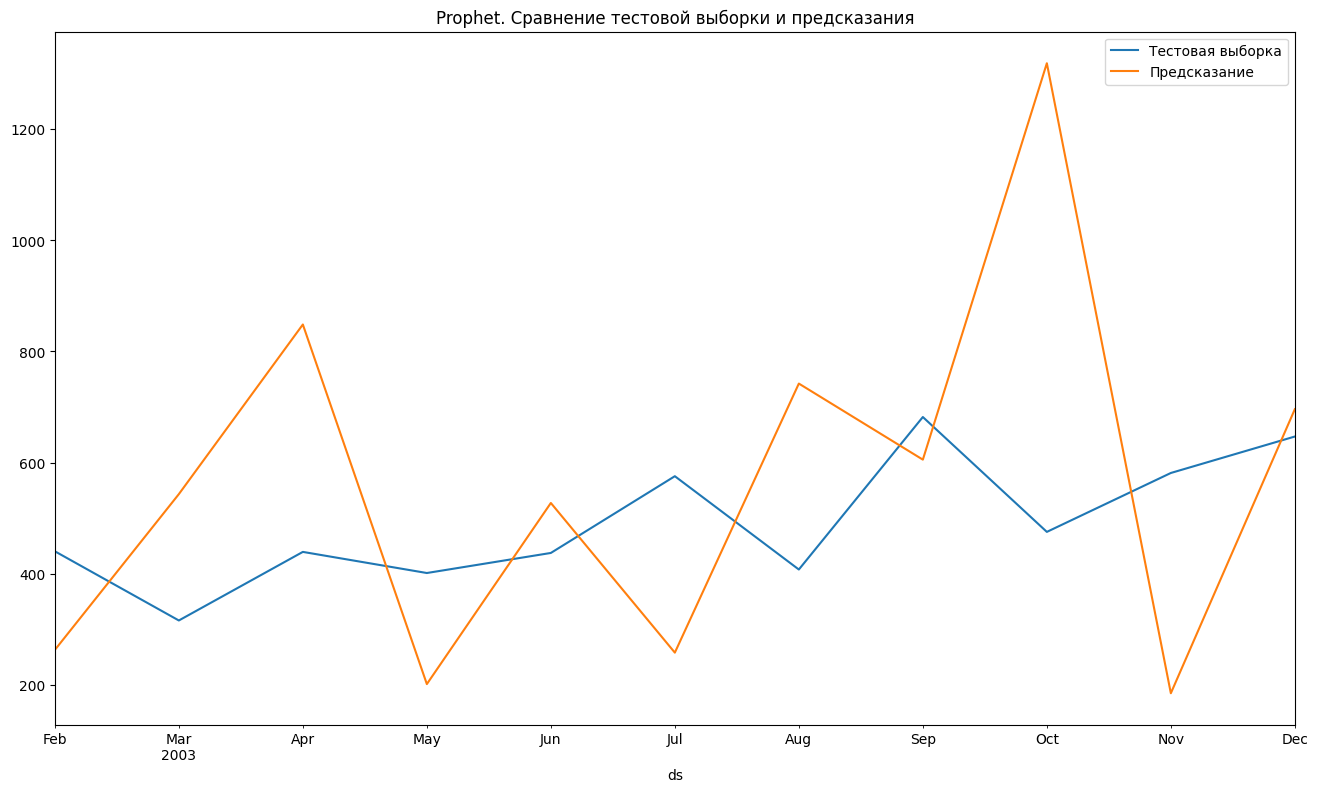

In [503]:
ax1 = p_prediction['y'].plot(legend=True, title='Prophet. Сравнение тестовой выборки и предсказания')
ax2 = p_prediction['yhat'].plot(figsize=(16,9), legend=True) \
  .legend(['Тестовая выборка', 'Предсказание'])

# <font color='#11a642' size='6'>  Извлечение признаков с помощью tsfresh

In [504]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import make_forecasting_frame
from tsfresh.feature_extraction import EfficientFCParameters

In [36]:
ts

,Sales
date,
2001-01-01,266.0
2001-02-01,145.9
2001-03-01,183.1
2001-04-01,119.3
2001-05-01,180.3
2001-06-01,168.5
2001-07-01,231.8
2001-08-01,224.5
2001-09-01,192.8


In [505]:
# 2. Подготовка данных для прогнозирования
# Используем make_forecasting_frame для создания лаговых признаков
df_shift, y = make_forecasting_frame(ts, kind="Sales", max_timeshift=10, rolling_direction=1)


/usr/local/lib/python3.11/dist-packages/tsfresh/utilities/dataframe_functions.py:520: UserWarning:

Your time stamps are not uniformly sampled, which makes rolling nonsensical in some domains.

Rolling: 100%|██████████| 36/36 [00:00<00:00, 250.86it/s]


In [506]:
df_shift.head(20)

,id,time,value,kind
1,"(id, 2001-02-01 00:00:00)",2001-01-01,266.0,Sales
3,"(id, 2001-03-01 00:00:00)",2001-01-01,266.0,Sales
4,"(id, 2001-03-01 00:00:00)",2001-02-01,145.9,Sales
6,"(id, 2001-04-01 00:00:00)",2001-01-01,266.0,Sales
7,"(id, 2001-04-01 00:00:00)",2001-02-01,145.9,Sales
8,"(id, 2001-04-01 00:00:00)",2001-03-01,183.1,Sales
10,"(id, 2001-05-01 00:00:00)",2001-01-01,266.0,Sales
11,"(id, 2001-05-01 00:00:00)",2001-02-01,145.9,Sales
12,"(id, 2001-05-01 00:00:00)",2001-03-01,183.1,Sales
13,"(id, 2001-05-01 00:00:00)",2001-04-01,119.3,Sales


In [507]:
y.head()

,value
"(id, 2001-02-01 00:00:00)",145.9
"(id, 2001-03-01 00:00:00)",183.1
"(id, 2001-04-01 00:00:00)",119.3
"(id, 2001-05-01 00:00:00)",180.3
"(id, 2001-06-01 00:00:00)",168.5


In [508]:
# 3. Извлечение признаков с помощью tsfresh
# Используем базовый набор признаков для скорости (можно использовать ComprehensiveFCParameters для всех признаков)
fc_parameters = EfficientFCParameters()

X = extract_features(
    df_shift,
    column_id="id",
    column_sort="time",
    column_value="value",
    default_fc_parameters=fc_parameters,
    # мы можем отключить параллельную обработку для отладки
    disable_progressbar=False,
    show_warnings=False
)

Feature Extraction: 100%|██████████| 35/35 [00:03<00:00, 10.08it/s]


In [509]:
X.head()

value__variance_larger_than_standard_deviation  \
id 2001-02-01                                             0.0   
   2001-03-01                                             1.0   
   2001-04-01                                             1.0   
   2001-05-01                                             1.0   
   2001-06-01                                             1.0   

               value__has_duplicate_max  value__has_duplicate_min  \
id 2001-02-01                       0.0                       0.0   
   2001-03-01                       0.0                       0.0   
   2001-04-01                       0.0                       0.0   
   2001-05-01                       0.0                       0.0   
   2001-06-01                       0.0                       0.0   

               value__has_duplicate  value__sum_values  value__abs_energy  \
id 2001-02-01                   0.0              266.0           70756.00   
   2001-03-01                   0.0              411.9           92042.81   
   2001-04-01                   0.0              595.0          125568.42   
   2001-05-01                   0.0              714.3          139800.91   
   2001-06-01                   0.0              894.6          172309.00   

               value__mean_abs_change  value__mean_change  \
id 2001-02-01                     NaN                 NaN   
   2001-03-01                 120.100            -120.100   
   2001-04-01                  78.650             -41.450   
   2001-05-01                  73.700             -48.900   
   2001-06-01                  70.525             -21.425   

               value__mean_second_derivative_central  value__median  ...  \
id 2001-02-01                                    NaN         266.00  ...   
   2001-03-01                                    NaN         205.95  ...   
   2001-04-01                              78.650000         183.10  ...   
   2001-05-01                              14.075000         164.50  ...   
   2001-06-01                              30.183333         180.30  ...   

               value__fourier_entropy__bins_5  \
id 2001-02-01                             NaN   
   2001-03-01                       -0.000000   
   2001-04-01                        0.693147   
   2001-05-01                        1.098612   
   2001-06-01                        0.636514   

               value__fourier_entropy__bins_10  \
id 2001-02-01                              NaN   
   2001-03-01                        -0.000000   
   2001-04-01                         0.693147   
   2001-05-01                         1.098612   
   2001-06-01                         0.636514   

               value__fourier_entropy__bins_100  \
id 2001-02-01                               NaN   
   2001-03-01                         -0.000000   
   2001-04-01                          0.693147   
   2001-05-01                          1.098612   
   2001-06-01                          1.098612   

               value__permutation_entropy__dimension_3__tau_1  \
id 2001-02-01                                             NaN   
   2001-03-01                                             NaN   
   2001-04-01                                       -0.000000   
   2001-05-01                                        0.693147   
   2001-06-01                                        0.636514   

               value__permutation_entropy__dimension_4__tau_1  \
id 2001-02-01                                             NaN   
   2001-03-01                                             NaN   
   2001-04-01                                             NaN   
   2001-05-01                                       -0.000000   
   2001-06-01                                        0.693147   

               value__permutation_entropy__dimension_5__tau_1  \
id 2001-02-01                                             NaN   
   2001-03-01                                             NaN   
   2001-04-01                             

In [511]:
# 4. Разделение на обучающую и тестовую выборки
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [512]:
# 5. Обучение модели Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [513]:
# 6. Прогнозирование и оценка модели
y_pred = model.predict(X_test)

In [514]:
# Вычисляем метрики
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nMAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 209.862
RMSE: 230.983


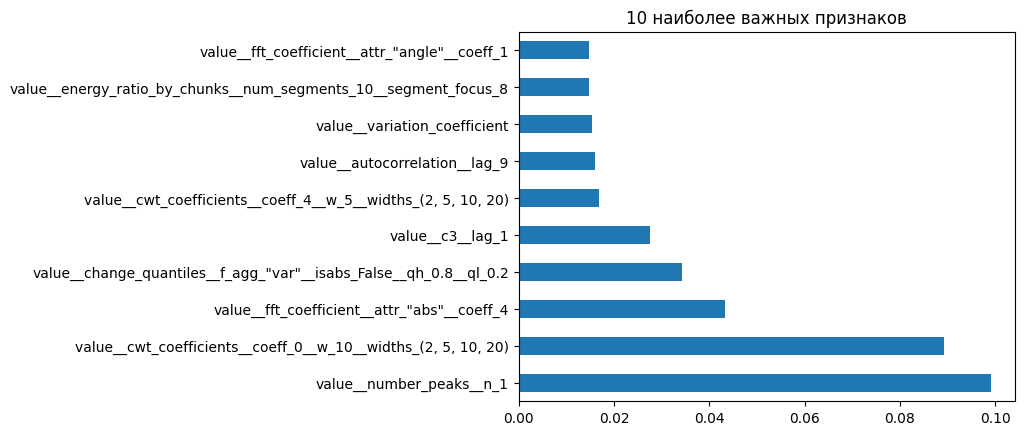

In [516]:
# 7. Важность признаков
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('10 наиболее важных признаков')
plt.show()